In [6]:
!uv pip install kagglehub tensorflow matplotlib numpy --quiet

In [7]:
import kagglehub
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

In [8]:
import os

print(f"Path: {path}")
print(f"Contents of path: {os.listdir(path)}")

Path: /Users/kevin/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1
Contents of path: ['PlantVillage']


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers

import matplotlib.pyplot as plt
import numpy as np

In [10]:
DIRECTORY=f"{path}/PlantVillage/"
IMAGE_SIZE=256
BATCH_SIZE=128
CHANNELS=3
VERBOSE=1
EPOCHS=2

In [11]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DIRECTORY,
    seed=42,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


In [53]:
class_names = dataset.class_names
len(class_names)
print(dataset.class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [13]:
len(dataset)

162

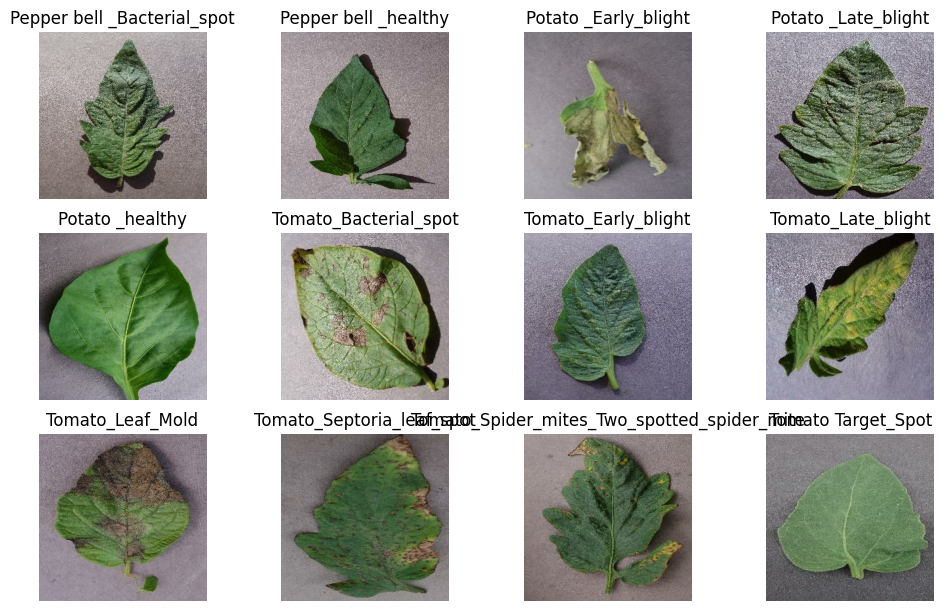

In [14]:
for image_batch, label_batch in dataset.take(1):
  plt.figure(figsize=(12, 10))

  for idx in range(12):
    ax = plt.subplot(4, 4, idx + 1)
    plt.imshow(image_batch[idx].numpy().astype("uint8"))
    plt.title(class_names[idx].replace("__", " "))
    plt.axis("off")

In [15]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
  ds_size = len(ds)

  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=42)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds, val_ds, test_ds


In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [17]:
len(train_ds), len(val_ds), len(test_ds)

(129, 16, 17)

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [21]:
input_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 15

model = models.Sequential([
    resize_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model.build(input_shape=input_shape)

/Users/kevin/Desktop/engineer/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (128, 256, 256, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (128, 256, 256, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (128, 254, 254, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (128, 127, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (128, 125, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (128, 62, 62, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (128, 60, 60, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (128, 30, 30, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (128, 28, 28, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (128, 14, 14, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (128, 12, 12, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (128, 6, 6, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (128, 2304)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 64)              │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (128, 15)              │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,671 (1.06 MB)

 Trainable params: 278,671 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [51]:
version = len(os.listdir("./models")) + 1

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3),
    keras.callbacks.ModelCheckpoint(f"./models/plant_village_v{version}.keras", save_best_only=True)
]

callbacks

In [25]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=VERBOSE,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/2
129/129 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.3325 - loss: 2.0736 - val_accuracy: 0.5269 - val_loss: 1.4729 - learning_rate: 0.0010
Epoch 2/2
129/129 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.6047 - loss: 1.2225 - val_accuracy: 0.5635 - val_loss: 1.4678 - learning_rate: 0.0010


In [26]:
scores = model.evaluate(test_ds)

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 406ms/step - accuracy: 0.5570 - loss: 1.4460


In [27]:
scores

[1.4459835290908813, 0.5569853186607361]

In [28]:
history

In [29]:
history.params

{'verbose': 1, 'epochs': 2, 'steps': 129}

In [30]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [31]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

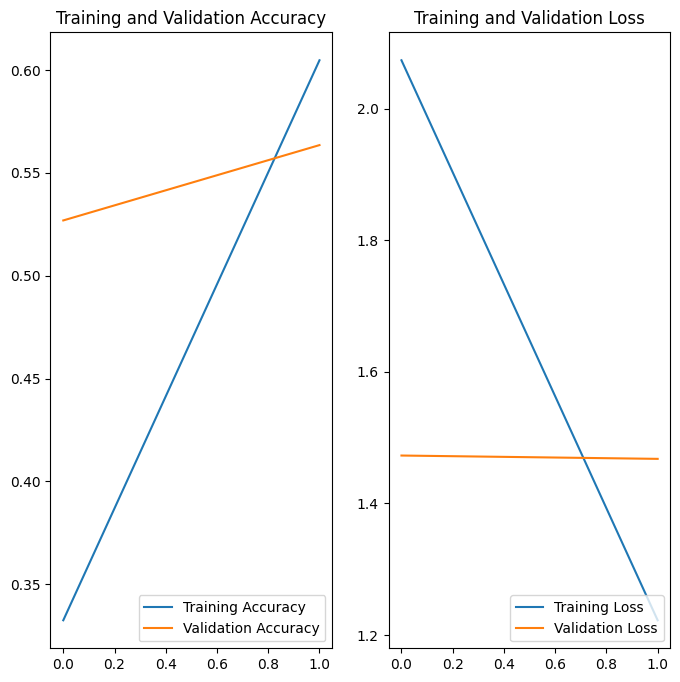

In [32]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)

plt.plot(range(EPOCHS), accuracy, label="Training Accuracy")
plt.plot(range(EPOCHS), val_accuracy, label="Validation Accuracy")

plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")


plt.subplot(1, 2, 2)

plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")

plt.legend(loc="lower right")
plt.title("Training and Validation Loss")

First image to predict
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Actual label:       Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted label:    Tomato__Tomato_YellowLeaf__Curl_Virus
Result: True


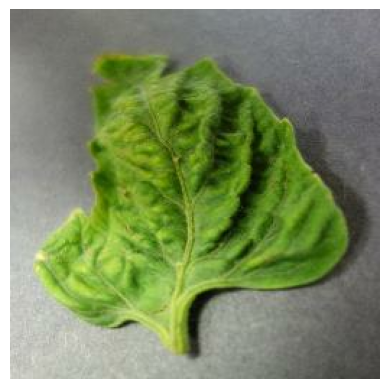

In [33]:
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0]

    print("First image to predict")
    plt.imshow(first_image)
    plt.axis("off")
    
    batch_prediction = model.predict(images_batch)

    actual_label = class_names[first_label]
    print(f"Actual label:       {actual_label}")

    predicted_label = class_names[np.argmax(batch_prediction[0])]
    print(f"Predicted label:    {predicted_label}")

    print(F"Result: {actual_label == predicted_label}")


In [50]:
version = len(os.listdir("./models")) + 1
model.save(f"./models/plant_village_v{version}.keras")

1